DATA SCIENCE AND DATA ANALYTICS PROJECT 1 : 

CASE SCENARIO : Alpha dreamers Banking consortium is a financial institution that provides business loans, savings accounts, and checking accounts for individuals and businesses. In their annual review, the board of directors for the institution saw it fit to enhance its internal operations to stay ahead of the competition. A new wing of business intelligence has been initiated to assist the loans department to automate, predict and formalize the business processes. The loans department has realized that there is a high defaulter rate for personal loans and measures must be put in place to minimize the defaulter rates.


In [1]:
import numpy as np
import pandas as pd 
Bank_data= pd.read_csv("C:/Users/fngom/Desktop/CSEdata.csv")
Bank_data.head(10)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
5,6,6915937,64,0,single,rented,no,Civil_servant,Jalgaon,Maharashtra,0,12,0
6,7,3954973,58,14,married,rented,no,Librarian,Tiruppur,Tamil_Nadu,8,12,0
7,8,1706172,33,2,single,rented,no,Economist,Jamnagar,Gujarat,2,14,0
8,9,7566849,24,17,single,rented,yes,Flight_attendant,Kota[6],Rajasthan,11,11,0
9,10,8964846,23,12,single,rented,no,Architect,Karimnagar,Telangana,5,13,0


In [2]:
# Checking for missing values from the data
print ('Missing Values') 
print (Bank_data.isnull().sum())

Missing Values
Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64


In [3]:
Bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   Married/Single     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB


SPLITING THE DATA INTO THE TRAIN AND TEST DATA (80% : 20%)

In [4]:
import pandas as pd 
from sklearn.model_selection import train_test_split

Bank_data= pd.read_csv ("C:/Users/fngom/Desktop/CSEdata.csv")

# Defining the target (y) and the inputs / features (x)
y= Bank_data['Risk_Flag']
x= Bank_data.drop('Risk_Flag', axis =1 )
# the X statement means we are dropping a colunm (axis=1). And that colunm is the Targert (risk flag)

# Now we split the data into a Train (80%) and Test(20%) data set 
x_Train, x_Test, y_Train, y_Test = train_test_split (x,y,
    test_size=0.2, random_state=42)

# Combine the x_train and y_train into a single dataframe (which includes the risk flag)
train_bank_data=pd.concat([x_Train, y_Train], axis=1)

#Recombine into a single dataframe for testing( exlude the Risk_flag)
test_bank_data= x_Test.copy() # only the features no target

print ('Training data:', train_bank_data.shape)
print ('Test data:', test_bank_data.shape)


# Verify percentages 
total = len(Bank_data)
train_pct = len(train_bank_data) / total * 100 
test_pct = len(test_bank_data) / total * 100 
print(f"Training proportion: {train_pct:.2f}%") 
print(f"Test proportion: {test_pct:.2f}%")

print("Training data:", x_Train.shape) 
print("Test data:", x_Test.shape)

Training data: (201600, 13)
Test data: (50400, 12)
Training proportion: 80.00%
Test proportion: 20.00%
Training data: (201600, 12)
Test data: (50400, 12)


In [5]:
 #Load the train_bank_data
train_bank_data.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
200471,200472,9121364,70,18,single,rented,no,Artist,Sikar,Rajasthan,3,11,0
92611,92612,2636544,39,0,single,rented,no,Computer_hardware_engineer,Vellore,Tamil_Nadu,0,11,0
86397,86398,1010539,39,9,single,rented,no,Secretary,Hyderabad,Telangana,4,13,0
110500,110501,3897430,21,2,single,rented,no,Technician,Tinsukia,Assam,2,12,0
185133,185134,9470213,41,5,single,norent_noown,yes,Web_designer,Bidar,Karnataka,5,13,0


In [6]:
test_bank_data.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
75255,75256,4260981,47,18,single,rented,no,Politician,Hindupur,Andhra_Pradesh,7,13
192435,192436,8529345,44,2,single,rented,no,Computer_hardware_engineer,Narasaraopet,Andhra_Pradesh,2,10
154839,154840,7848654,55,9,single,rented,no,Software_Developer,Patna,Bihar,9,13
59774,59775,8491491,61,20,single,rented,no,Comedian,Haldia,West_Bengal,8,11
63788,63789,1537266,78,13,single,rented,no,Web_designer,Coimbatore,Tamil_Nadu,9,12


ADVANCED VISUALIZATION TO SEE PATTERNS AND SEE WHICH FEATURES INFLUENCE THE RISK FLAG.

THIS ALSO INCLUDES FEATURE ENGINEERING PROCESSES LIKE BINNING AND COMBINING TWO FEATURES TO MAKE A SINGLE BETTER FEATURE 

(a) Income Bracket

Does Income bracket of loan applicants influence their Risk Flag ?

In [7]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
#plt.rcParams('figure.figsize') =(6,4)

# Feature Engineering income into income bracket . This is called income binning 

# Step 1 : define the categories of our income bins or categiries 

Income_bins= [10310,3318935,6647587,9999938]
Income_labels= ['Low(10310-3318935)', 'Middle(33189356 - 6647587)', 'High(6647588+)']

train_bank_data['Income_bracket']= pd.cut(train_bank_data['Income'], bins =Income_bins, labels =Income_labels, right=False)
test_bank_data['Income_bracket']=pd.cut(test_bank_data['Income'],bins=Income_bins, labels= Income_labels, right =False )

print ( 'Feature Engineered' 'Income_Bracket' 'feature using binning ')

Feature EngineeredIncome_Bracketfeature using binning 


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\1033508655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_bracket', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Income_labels)


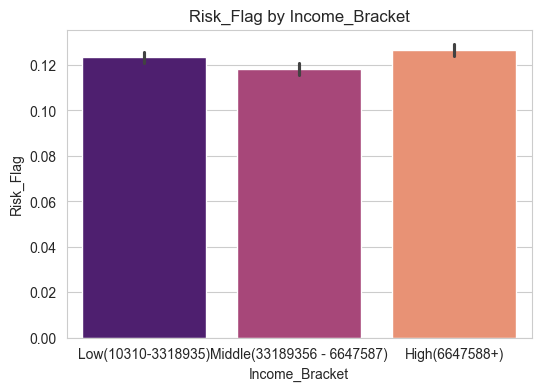

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x='Income_bracket', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Income_labels)
plt.title('Risk_Flag by Income_Bracket')
plt.ylabel('Risk_Flag')
plt.xlabel('Income_Bracket')
plt.show()

ANSWER : NOT REALLY . THE DIFFERENCE VALUE OF RISK FLAG AMONG THE THREE IS VERY SMALL

 AGE CATEGORY

In [9]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
#plt.rcParams('figure.figsize') =(6,4)

# Feature Engineering AGE into AGE bracket . This is called AGE binning 

# Step 1 : define the categories of our AGE bins or categiries 

Age_bins= [21,30,55,100]
Age_labels= ['Youth(21-30)', 'Middle_Aged(31-55)', 'Senior(55+)']

train_bank_data['Age_Category']= pd.cut(train_bank_data['Age'], bins =Age_bins, labels =Age_labels, right=False)
test_bank_data['Age_Category']=pd.cut(test_bank_data['Age'],bins=Age_bins, labels= Age_labels, right =False )

print("Engineered 'Age_Category' feature through binning")

Engineered 'Age_Category' feature through binning


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\3514301594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Category', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Age_labels)


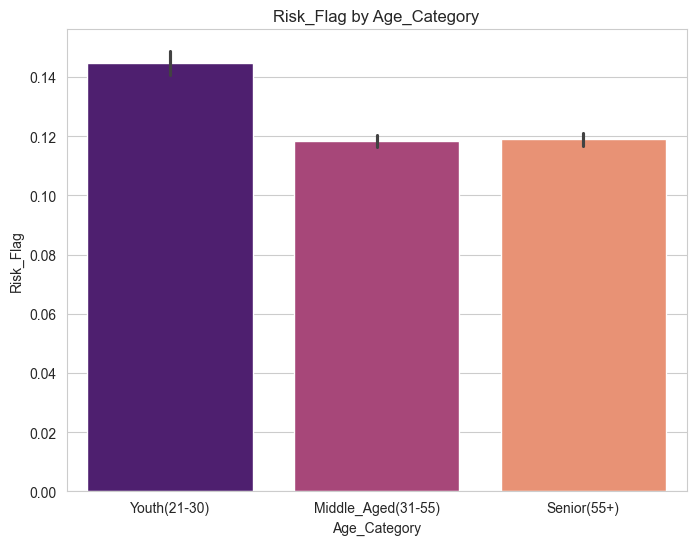

Age vs Risk flag


In [10]:
plt.figure(figsize=(8,6))
sns.barplot(x='Age_Category', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Age_labels)
plt.title('Risk_Flag by Age_Category')
plt.ylabel('Risk_Flag')
plt.xlabel('Age_Category')
plt.show()

print ( 'Age vs Risk flag')

 PEOPLE WITHIN THE YOUTH  AGE GROUP (21-30) HAVE A HIGH RISK FLAG. FOLLOWED BY MIDDLE-AGED PEOPLE , THEN SENIOR PEOPLE

 CAR OWNERSHIP:
 
  DOES HAVING A CAR INFLUENCE THE RISK FLAG

In [11]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Map out the value where: 0 = No Car, 1 = Have a Car
train_bank_data['Car_Owner'] = train_bank_data['Car_Ownership'].replace({0:0, 1:1})
test_bank_data['Car_Owner'] = test_bank_data['Car_Ownership'].replace({0:0, 1:1})

print("Engineered feature of Car_Ownership (0 = No Car, 1 = Have a Car)")
print(train_bank_data[['Car_Owner', 'Car_Ownership']].head())

Engineered feature of Car_Ownership (0 = No Car, 1 = Have a Car)
       Car_Owner Car_Ownership
200471        no            no
92611         no            no
86397         no            no
110500        no            no
185133       yes           yes


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\4247473031.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\4247473031.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


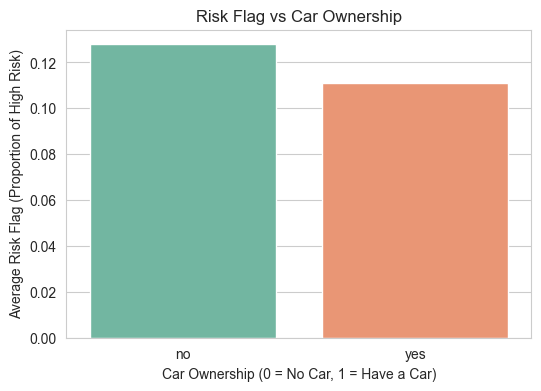

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot showing proportion of risk by car ownership
plt.figure(figsize=(6,4))
sns.barplot(
    data=train_bank_data,
    x='Car_Ownership',
    y='Risk_Flag',
    ci=None,
    palette='Set2'
)

plt.title("Risk Flag vs Car Ownership")
plt.xlabel("Car Ownership (0 = No Car, 1 = Have a Car)")
plt.ylabel("Average Risk Flag (Proportion of High Risk)")
plt.show()

HAVING A CAR = LESS RISK
NO CAR = HIGH RISK

MARITAL STATUS : 

MARRIED / SINGLE

In [13]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

#Map out the value where: 0= Single , 1= Married
train_bank_data['Marital_Status']= train_bank_data['Married/Single'].replace({0:0,1:1})
test_bank_data ['Marital_Status']= test_bank_data['Married/Single'].replace({0:0,1:1}) 

print ('Engineered feature of Marital_Status (0=Single, 1=Married)')

Engineered feature of Marital_Status (0=Single, 1=Married)


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\3213135944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


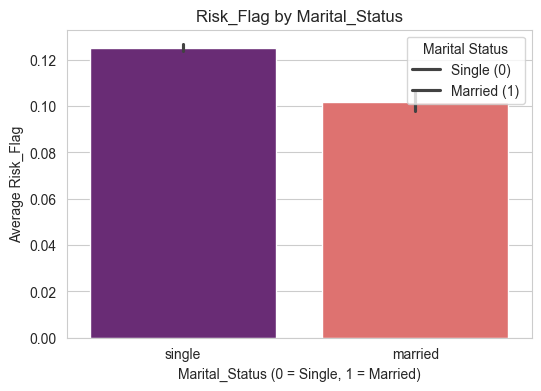

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    x='Marital_Status', 
    y='Risk_Flag', 
    data=train_bank_data, 
    palette='magma'
)

plt.title('Risk_Flag by Marital_Status')
plt.ylabel('Average Risk_Flag')
plt.xlabel('Marital_Status (0 = Single, 1 = Married)')

# Add legend manually
plt.legend(
    title='Marital Status',
    labels=['Single (0)', 'Married (1)'],
    loc='upper right'
)

plt.show()


SINGLE = HIGH RISK
MARRIED = LOW RISK

EXPERIENCE LEVEL : 

JUNIOR 
INTERMEDIATE
MID -LEVEL
SENIOR 

In [15]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
#plt.rcParams('figure.figsize') =(6,4)

# Feature Engineering income into income bracket . This is called income binning 

# Step 1 : define the categories of our income bins or categiries 

Experience_bins= [0,2,5,10,float('inf') ]
Experience_labels= ['Junior(0-2)', 'Intermediate(2-5)', 'Mid-Level(5-10)', 'Senior(10+)']

train_bank_data['Experience_Level']= pd.cut(train_bank_data['Experience'], bins =Experience_bins, labels =Experience_labels, right=False)
test_bank_data['Experience_Level']=pd.cut(test_bank_data['Experience'],bins=Experience_bins, labels= Experience_labels, right =False )

print("Engineered 'Experience_Level' feature through binning")


Engineered 'Experience_Level' feature through binning


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\1426528319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Experience_Level', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Experience_labels)


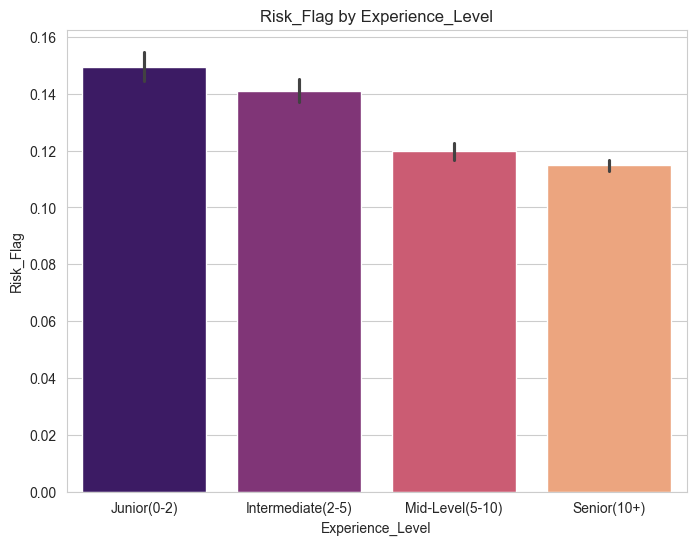

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(x='Experience_Level', y='Risk_Flag', data=train_bank_data, palette= 'magma', order=Experience_labels)
plt.title('Risk_Flag by Experience_Level')
plt.ylabel('Risk_Flag')
plt.xlabel('Experience_Level')
plt.show()

AS YEARS OF EXPERIENCE INCREASE , RISK FLAG DECREASES 

JOB STABILITY RATIO: 
COMBINATION OF CURRENT JOB YEARS AND EXPERINCE 

In [17]:
train_bank_data['Job_Stability_Ratio'] = np.where(
    train_bank_data['Experience'] > 0,
    train_bank_data['CURRENT_JOB_YRS'] / train_bank_data['Experience'],
    0
)

C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\4019137184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


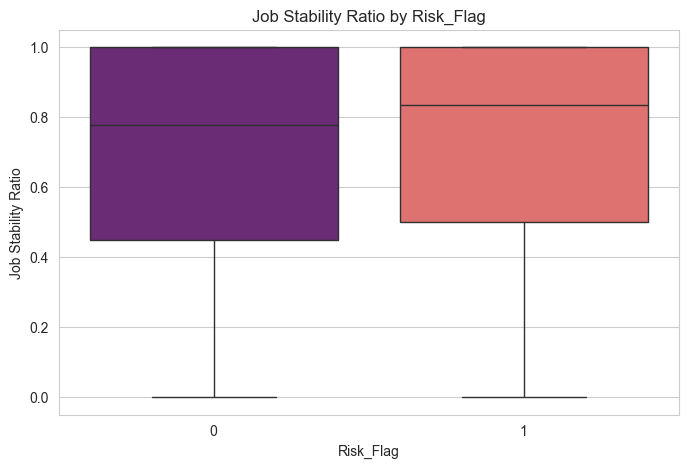

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Risk_Flag',
    y='Job_Stability_Ratio',
    data=train_bank_data,
    palette='magma'
)

plt.title('Job Stability Ratio by Risk_Flag')
plt.xlabel('Risk_Flag')
plt.ylabel('Job Stability Ratio')
plt.show()


In [19]:
import pandas as pd
import numpy as np

# Create Residential Stability Ratio feature
train_bank_data['Residential_Stability_Ratio'] = np.where(train_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)
test_bank_data['Residential_Stability_Ratio'] = np.where(test_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)

print("Engineered 'Residential_Stability_Ratio' feature")
print(train_bank_data[['CURRENT_HOUSE_YRS', 'Residential_Stability_Ratio']].head())


Engineered 'Residential_Stability_Ratio' feature
        CURRENT_HOUSE_YRS  Residential_Stability_Ratio
200471                 11                            1
92611                  11                            1
86397                  13                            1
110500                 12                            1
185133                 13                            1


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\3885711063.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\3885711063.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


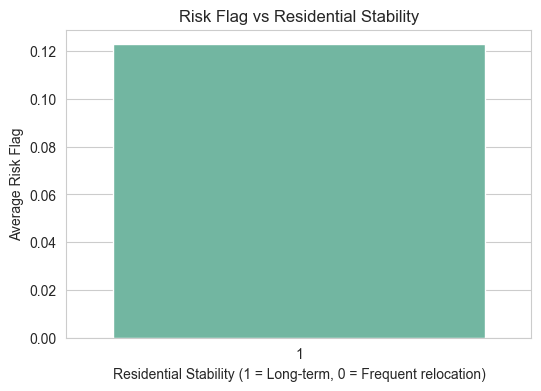

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot showing average risk by stability category
plt.figure(figsize=(6,4))
sns.barplot(
    data=train_bank_data,
    x='Residential_Stability_Ratio',
    y='Risk_Flag',
    ci=None,
    palette='Set2'
)

plt.title("Risk Flag vs Residential Stability")
plt.xlabel("Residential Stability (1 = Long-term, 0 = Frequent relocation)")
plt.ylabel("Average Risk Flag")
plt.show()

RISK FLAG BY GEOGRAPHICAL LOCATION (STATE)

In [21]:
# Group by State and calculate mean risk_flag
state_risk_mean = train_bank_data.groupby('STATE')['Risk_Flag'].mean().reset_index()

# Rename for clarity
state_risk_mean.rename(columns={'Risk_Flag': 'Mean_Risk_Flag'}, inplace=True)

print(state_risk_mean.head())


            STATE  Mean_Risk_Flag
0  Andhra_Pradesh        0.116077
1           Assam        0.133547
2           Bihar        0.130800
3      Chandigarh        0.085657
4    Chhattisgarh        0.132261


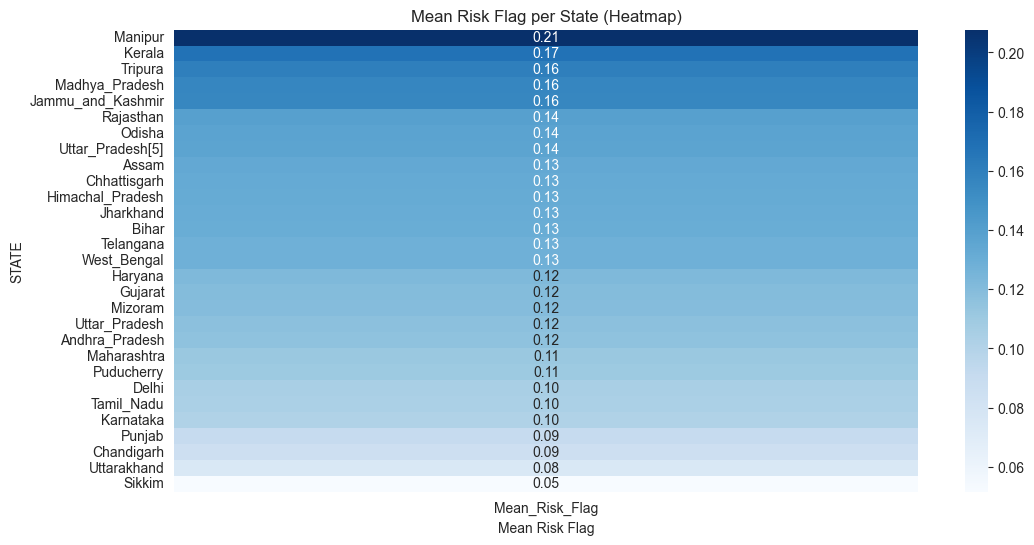

In [22]:
# Pivot the data so we can use it in a heatmap
heatmap_data = state_risk_mean.pivot_table(index='STATE', values='Mean_Risk_Flag')

# Sort states for cleaner visualization
heatmap_data = heatmap_data.sort_values('Mean_Risk_Flag', ascending=False)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt=".2f")
plt.title('Mean Risk Flag per State (Heatmap)')
plt.ylabel('STATE')
plt.xlabel('Mean Risk Flag')
plt.show()



MANIPUR STATE = HIGH MEAN RISK FLAG
 
SIKKIM= LOW MEAN RISK FLAG

RISK FLAG BY PROFFESSION 

In [23]:
print(train_bank_data['Profession'].unique())


<StringArray>
[                    'Artist', 'Computer_hardware_engineer',
                  'Secretary',                 'Technician',
               'Web_designer',                     'Lawyer',
          'Chemical_engineer',                'Firefighter',
                  'Librarian',                    'Drafter',
                   'Designer',               'Statistician',
                   'Comedian',          'Financial_Analyst',
             'Civil_engineer',                   'Engineer',
              'Civil_servant',                    'Surgeon',
                 'Magistrate',     'Air_traffic_controller',
         'Software_Developer',       'Chartered_Accountant',
        'Mechanical_engineer',      'Technology_specialist',
                  'Architect',                  'Physician',
               'Army_officer',           'Flight_attendant',
           'Graphic_Designer',                  'Economist',
           'Fashion_Designer',           'Technical_writer',
          

In [24]:
# Define profession mapping
profession_map = {
    'Engineer': 'Technical',
    'Doctor': 'Healthcare',
    'Nurse': 'Healthcare',
    'Teacher': 'Education',
    'Professor': 'Education',
    'Businessman': 'Business',
    'Entrepreneur': 'Business',
    'Artist':'Entertainment',
    'Computer_hardware_enginner': 'IT',
    'Web_designer': 'IT',
    'Technician': 'Technical',
    'Secretary':'Business',

    # Add other mappings as needed
}

# Apply mapping
train_bank_data['Profession_Type'] = train_bank_data['Profession'].map(profession_map).fillna('Other')
test_bank_data['Profession_Type'] = test_bank_data['Profession'].map(profession_map).fillna('Other')

print(train_bank_data[['Profession','Profession_Type']].head())


                        Profession Profession_Type
200471                      Artist   Entertainment
92611   Computer_hardware_engineer           Other
86397                    Secretary        Business
110500                  Technician       Technical
185133                Web_designer              IT


In [25]:
# Compute mean risk per profession type
profession_risk_mean = train_bank_data.groupby('Profession_Type')['Risk_Flag'].mean().reset_index()
profession_risk_mean.rename(columns={'Risk_Flag':'Mean_Risk_Flag'}, inplace=True)

# Pivot for heatmap 
pivot_table = profession_risk_mean.pivot_table(index='Profession_Type', values='Mean_Risk_Flag')


profession_risk_mean['Scaled_Risk_Flag'] = (
    (profession_risk_mean['Mean_Risk_Flag'] - profession_risk_mean['Mean_Risk_Flag'].min()) /
    (profession_risk_mean['Mean_Risk_Flag'].max() - profession_risk_mean['Mean_Risk_Flag'].min())
)


In [26]:
train_bank_data = train_bank_data.merge(profession_risk_mean[['Profession_Type','Scaled_Risk_Flag']], 
                                        on='Profession_Type', how='left')
test_bank_data = test_bank_data.merge(profession_risk_mean[['Profession_Type','Scaled_Risk_Flag']], 
                                      on='Profession_Type', how='left')

C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\3676455951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profession_risk_mean, x='Profession_Type', y='Scaled_Risk_Flag', palette="Blues")


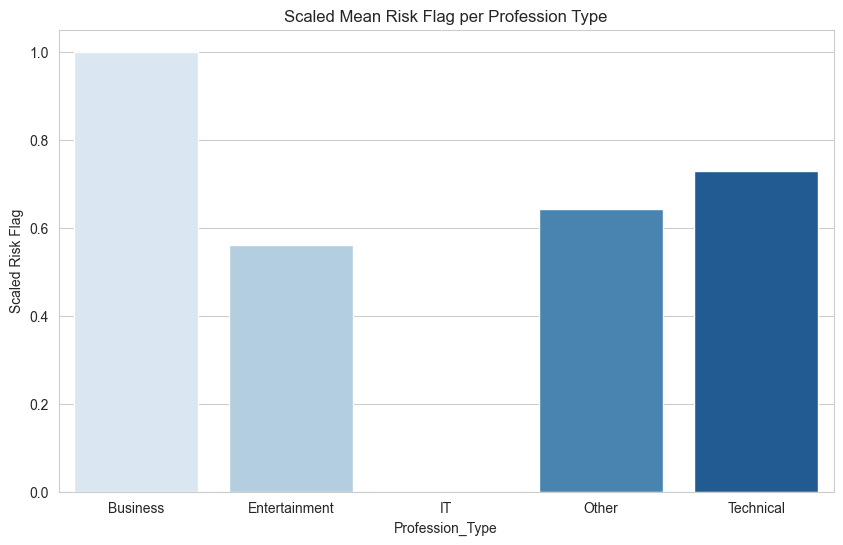

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(data=profession_risk_mean, x='Profession_Type', y='Scaled_Risk_Flag', palette="Blues")
plt.title('Scaled Mean Risk Flag per Profession Type')
plt.ylabel('Scaled Risk Flag')
plt.show()

BUSSINESS PROFESSION = HIGH RISK FLAG 
IT = LOW RISK FLAG

INTERACTIONS BETWEEN FEATURES 

AGE AND EXPERIENCE LEVEL

Interaction of Age_Category & Experience_Level vs Risk_Flag (%):
Risk_Flag                                 0      1
Age_Category       Experience_Level               
Youth(21-30)       Junior(0-2)        78.34  21.66
                   Intermediate(2-5)  85.87  14.13
                   Mid-Level(5-10)    87.65  12.35
                   Senior(10+)        85.80  14.20
Middle_Aged(31-55) Junior(0-2)        85.81  14.19
                   Intermediate(2-5)  85.38  14.62
                   Mid-Level(5-10)    88.50  11.50
                   Senior(10+)        89.09  10.91
Senior(55+)        Junior(0-2)        86.95  13.05
                   Intermediate(2-5)  86.36  13.64
                   Mid-Level(5-10)    87.72  12.28
                   Senior(10+)        88.94  11.06


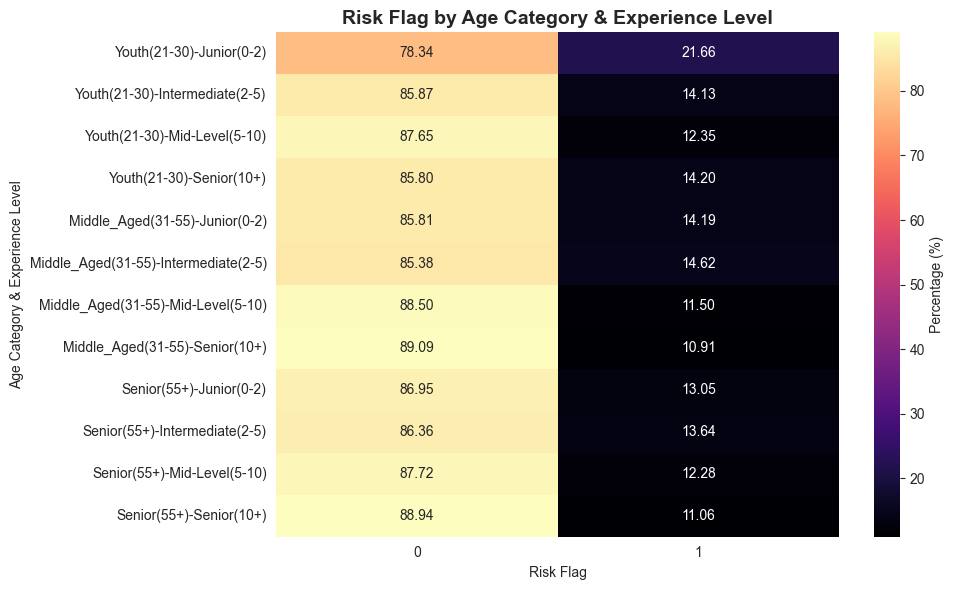

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab of Age_category & Experience_Level vs Risk_Flag
interaction_table = pd.crosstab(
    [train_bank_data['Age_Category'], train_bank_data['Experience_Level']],
    train_bank_data['Risk_Flag'],
    normalize='index'   # normalize by row → percentages
).mul(100).round(2)

print("Interaction of Age_Category & Experience_Level vs Risk_Flag (%):")
print(interaction_table)

# Reset index for plotting
interaction_table_reset = interaction_table.reset_index()

# Heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(
    interaction_table,
    annot=True, fmt=".2f", cmap="magma", cbar_kws={'label': 'Percentage (%)'}
)

plt.title("Risk Flag by Age Category & Experience Level", fontsize=14, fontweight='bold')
plt.xlabel("Risk Flag")
plt.ylabel("Age Category & Experience Level")
plt.tight_layout()
plt.show()


CAR OWNERSHIP AND MARITAL STATUS 

C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\232934711.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


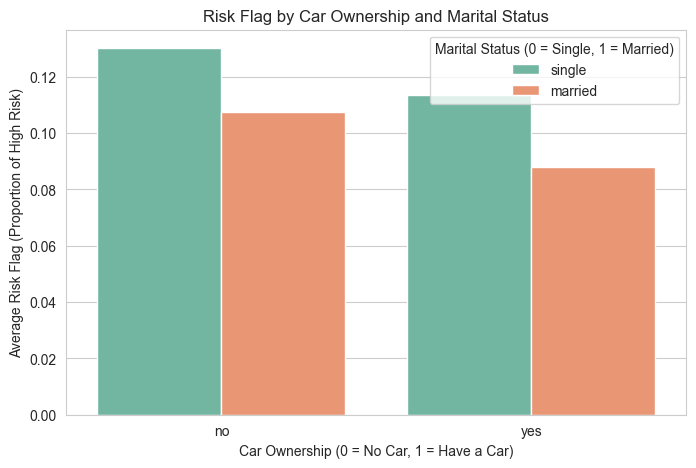

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot: Risk Flag vs Car Ownership & Marital Status
plt.figure(figsize=(8,5))
sns.barplot(
    data=train_bank_data,
    x='Car_Ownership',
    y='Risk_Flag',
    hue='Marital_Status',
    ci=None,
    palette='Set2'
)

plt.title("Risk Flag by Car Ownership and Marital Status")
plt.xlabel("Car Ownership (0 = No Car, 1 = Have a Car)")
plt.ylabel("Average Risk Flag (Proportion of High Risk)")
plt.legend(title="Marital Status (0 = Single, 1 = Married)")
plt.show()


AGE AND CAR OWNERSHIP

Risk_Flag                            0         1
Age_Category       Car_Owner                    
Youth(21-30)       no         0.851328  0.148672
                   yes        0.865150  0.134850
Middle_Aged(31-55) no         0.873100  0.126900
                   yes        0.900578  0.099422
Senior(55+)        no         0.878895  0.121105
                   yes        0.885857  0.114143


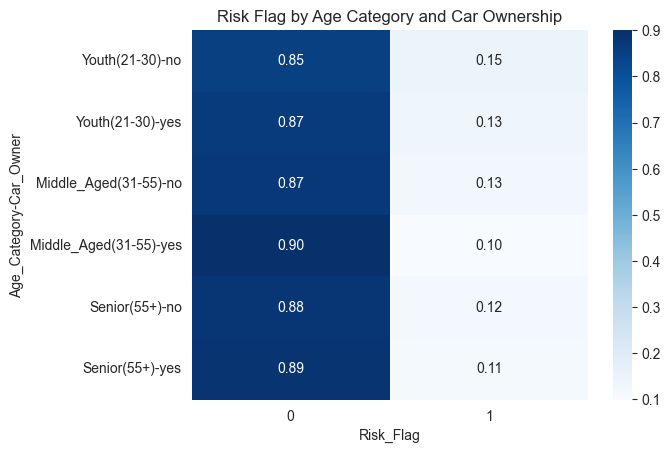

In [30]:
# Combined Age and Car Ownership vs Risk Flag
combined_ct = pd.crosstab(
    [train_bank_data['Age_Category'], train_bank_data['Car_Owner']],
    train_bank_data['Risk_Flag'],
    normalize='index'
)
print(combined_ct)

# Heatmap visualization
sns.heatmap(combined_ct, annot=True, cmap="Blues", fmt=".2f")
plt.title('Risk Flag by Age Category and Car Ownership')
plt.show()

CREATING A LOGISTIC REGRESSION MODEL 

In [31]:
import pandas as pd
import numpy as np

# -------------------------------
# AGE CATEGORY (binning)
# -------------------------------
Age_bins = [21, 30, 55, 100]
Age_labels = ['Youth(21-30)', 'Middle_Aged(31-55)', 'Senior(55+)']

train_bank_data['Age_Category'] = pd.cut(train_bank_data['Age'], 
                                         bins=Age_bins, labels=Age_labels, right=False)
test_bank_data['Age_Category'] = pd.cut(test_bank_data['Age'], 
                                        bins=Age_bins, labels=Age_labels, right=False)

print("Engineered 'Age_Category' feature through binning")

# -------------------------------
# CAR OWNERSHIP (binary mapping)
# -------------------------------
train_bank_data['Car_Owner'] = train_bank_data['Car_Ownership'].replace({0:0, 1:1})
test_bank_data['Car_Owner'] = test_bank_data['Car_Ownership'].replace({0:0, 1:1})

print("Engineered feature 'Car_Owner' (0 = No Car, 1 = Have a Car)")

# -------------------------------
# EXPERIENCE LEVEL (binning)
# -------------------------------
Experience_bins = [0, 2, 5, 10, float('inf')]
Experience_labels = ['Junior(0-2)', 'Intermediate(2-5)', 'Mid-Level(5-10)', 'Senior(10+)']

train_bank_data['Experience_Level'] = pd.cut(train_bank_data['Experience'], 
                                             bins=Experience_bins, labels=Experience_labels, right=False)
test_bank_data['Experience_Level'] = pd.cut(test_bank_data['Experience'], 
                                            bins=Experience_bins, labels=Experience_labels, right=False)

print("Engineered 'Experience_Level' feature through binning")

# -------------------------------
# MARITAL STATUS (binary mapping)
# -------------------------------
train_bank_data['Marital_Status'] = train_bank_data['Married/Single'].replace({0:0, 1:1})
test_bank_data['Marital_Status'] = test_bank_data['Married/Single'].replace({0:0, 1:1})

print("Engineered feature 'Marital_Status' (0 = Single, 1 = Married)")

# -------------------------------
# RESIDENTIAL STABILITY RATIO
# -------------------------------
train_bank_data['Residential_Stability_Ratio'] = np.where(train_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)
test_bank_data['Residential_Stability_Ratio'] = np.where(test_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)

print("Engineered 'Residential_Stability_Ratio' feature")


Engineered 'Age_Category' feature through binning
Engineered feature 'Car_Owner' (0 = No Car, 1 = Have a Car)
Engineered 'Experience_Level' feature through binning
Engineered feature 'Marital_Status' (0 = Single, 1 = Married)
Engineered 'Residential_Stability_Ratio' feature


Combining DataFrames for Uniform Encoding

In [32]:
import numpy as np
import pandas as pd


# STEP 1: Save target
y = train_bank_data['Risk_Flag'].copy()

# STEP 2: Create engineered features BEFORE dropping raw columns
# AGE CATEGORY
Age_bins = [21, 30, 55, 100]
Age_labels = ['Youth(21-30)', 'Middle_Aged(31-55)', 'Senior(55+)']
train_bank_data['Age_Category'] = pd.cut(train_bank_data['Age'], bins=Age_bins, labels=Age_labels, right=False)
test_bank_data['Age_Category'] = pd.cut(test_bank_data['Age'], bins=Age_bins, labels=Age_labels, right=False)

# EXPERIENCE LEVEL
Experience_bins = [0, 2, 5, 10, float('inf')]
Experience_labels = ['Junior(0-2)', 'Intermediate(2-5)', 'Mid-Level(5-10)', 'Senior(10+)']
train_bank_data['Experience_Level'] = pd.cut(train_bank_data['Experience'], bins=Experience_bins, labels=Experience_labels, right=False)
test_bank_data['Experience_Level'] = pd.cut(test_bank_data['Experience'], bins=Experience_bins, labels=Experience_labels, right=False)

# MARITAL STATUS
train_bank_data['Marital_Status'] = train_bank_data['Married/Single'].replace({0:0, 1:1})
test_bank_data['Marital_Status'] = test_bank_data['Married/Single'].replace({0:0, 1:1})

# CAR OWNERSHIP
train_bank_data['Car_Owner'] = train_bank_data['Car_Ownership'].replace({0:0, 1:1})
test_bank_data['Car_Owner'] = test_bank_data['Car_Ownership'].replace({0:0, 1:1})

# RESIDENTIAL STABILITY RATIO
train_bank_data['Residential_Stability_Ratio'] = np.where(train_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)
test_bank_data['Residential_Stability_Ratio'] = np.where(test_bank_data['CURRENT_HOUSE_YRS'] > 5, 1, 0)

# STEP 3: Now drop raw features you don’t want
features_to_drop = ['Risk_Flag', 'Id', 'CITY',  'Age', 'Experience', 'Married/Single', 'Car_Ownership']
train_bank_data = train_bank_data.drop(features_to_drop, axis=1, errors='ignore')
test_bank_data = test_bank_data.drop(features_to_drop[1:], axis=1, errors='ignore')

# STEP 4: Select features
original_features = ['Income', 'House_Ownership', 'CURRENT_JOB_YRS','Profession','STATE' ,'CURRENT_HOUSE_YRS']
engineered_features = ['Age_Category', 'Experience_Level', 'Marital_Status', 'Car_Owner', 'Residential_Stability_Ratio']

selected_features = original_features + engineered_features
X_train = train_bank_data[selected_features]
X_test = test_bank_data[selected_features]

# STEP 5: Combine for uniform encoding
combined_data = pd.concat([X_train, X_test], ignore_index=True)
print("Combined DataFrames for uniform encoding.")
print(f"Features ready for encoding: {combined_data.columns.tolist()}")


Combined DataFrames for uniform encoding.
Features ready for encoding: ['Income', 'House_Ownership', 'CURRENT_JOB_YRS', 'Profession', 'STATE', 'CURRENT_HOUSE_YRS', 'Age_Category', 'Experience_Level', 'Marital_Status', 'Car_Owner', 'Residential_Stability_Ratio']


In [33]:
if 'Risk_Flag' in train_bank_data.columns:
    y = train_bank_data['Risk_Flag']
else:
    print("Risk_Flag column not found in train_bank_data")


Risk_Flag column not found in train_bank_data


In [34]:
train_bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 201600 entries, 0 to 201599
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Income                       201600 non-null  int64   
 1   House_Ownership              201600 non-null  str     
 2   Profession                   201600 non-null  str     
 3   STATE                        201600 non-null  str     
 4   CURRENT_JOB_YRS              201600 non-null  int64   
 5   CURRENT_HOUSE_YRS            201600 non-null  int64   
 6   Income_bracket               201599 non-null  category
 7   Age_Category                 201600 non-null  category
 8   Car_Owner                    201600 non-null  str     
 9   Marital_Status               201600 non-null  str     
 10  Experience_Level             201600 non-null  category
 11  Job_Stability_Ratio          201600 non-null  float64 
 12  Residential_Stability_Ratio  201600 non-null  int64   


In [35]:

import numpy as np
import pandas as pd

# STEP 5: Combine for uniform encoding
#combined_data = pd.concat([X_train, X_test], ignore_index=True)
#print("Combined DataFrames for uniform encoding.")
#print(f"Features ready for encoding: {combined_data.columns.tolist()}")

# STEP 6: Identify categorical columns for encoding
categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Quick check: Inspect dtypes and unique values to spot int-coded categorical features
print("Data types of selected features:\n", combined_data.dtypes)

for col in combined_data.columns:
    unique_vals = combined_data[col].unique()
    if combined_data[col].dtype in ['int64', 'int32'] and len(unique_vals) < 20:
        print(f"Column '{col}' looks categorical (int-coded). Unique values: {unique_vals}")

# Convert int-coded categorical features to string
possible_categorical_int_features = ['House_Ownership', 'Profession', 'STATE']
for col in possible_categorical_int_features:
    if col in combined_data.columns and combined_data[col].dtype in ['int64', 'int32']:
        combined_data[col] = combined_data[col].astype(str)

# Update categorical columns list after conversion
categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns identified for encoding: {categorical_cols}")

# STEP 7: Perform One-Hot Encoding
combined_data_encoded = pd.get_dummies(combined_data, columns=categorical_cols, drop_first=True)

print(f"Encoded Data Shape: {combined_data_encoded.shape}")
print("Categorical features successfully encoded into numerical columns.")

# STEP 8: Split back into train and test sets
X_train_encoded = combined_data_encoded.iloc[:len(X_train), :]
X_test_encoded = combined_data_encoded.iloc[len(X_train):, :]

print("Train and Test sets are now ready for modeling.")
print(f"X_train shape: {X_train_encoded.shape}, X_test shape: {X_test_encoded.shape}")


Data types of selected features:
 Income                            int64
House_Ownership                     str
CURRENT_JOB_YRS                   int64
Profession                          str
STATE                               str
CURRENT_HOUSE_YRS                 int64
Age_Category                   category
Experience_Level               category
Marital_Status                      str
Car_Owner                           str
Residential_Stability_Ratio       int64
dtype: object
Column 'CURRENT_JOB_YRS' looks categorical (int-coded). Unique values: [ 3  0  4  2  5  1  7  9 12 10  6 11  8 13 14]
Column 'CURRENT_HOUSE_YRS' looks categorical (int-coded). Unique values: [11 13 12 14 10]
Column 'Residential_Stability_Ratio' looks categorical (int-coded). Unique values: [1]
Categorical columns identified for encoding: ['House_Ownership', 'Profession', 'STATE', 'Age_Category', 'Experience_Level', 'Marital_Status', 'Car_Owner']


C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\2471086361.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\fngom\AppData\Local\Temp\ipykernel_12428\2471086361.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See

Encoded Data Shape: (252000, 91)
Categorical features successfully encoded into numerical columns.
Train and Test sets are now ready for modeling.
X_train shape: (201600, 91), X_test shape: (50400, 91)


In [36]:
# STEP 9: Separate encoded data back into train and test sets
N = len(train_bank_data)  # number of rows in training set
X_final = combined_data_encoded.iloc[:N, :]   # training features
X_test_final_ready = combined_data_encoded.iloc[N:, :]  # test features

print(f"\nFinal Training Features (X_final) shape: {X_final.shape}")
print(f"Final Test Features (X_test_final_ready) shape: {X_test_final_ready.shape}")

# STEP 10: Split training data into train/validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print("\nData Split Complete, Ready for Phase 4:")
print(f"X_train (80% for training model): {X_train.shape}")
print(f"X_val (20% for local testing/validation): {X_val.shape}")



Final Training Features (X_final) shape: (201600, 91)
Final Test Features (X_test_final_ready) shape: (50400, 91)

Data Split Complete, Ready for Phase 4:
X_train (80% for training model): (161280, 91)
X_val (20% for local testing/validation): (40320, 91)


In [37]:
# STEP 11: Establish Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the model
log_reg_model = LogisticRegression(random_state=42, max_iter=2000)
log_reg_model.fit(X_train, y_train)

# Predict and evaluate on the unseen validation data (X_val)
y_pred_log_reg = log_reg_model.predict(X_val)
log_reg_accuracy = accuracy_score(y_val, y_pred_log_reg)

print(f"1. Logistic Regression Validation Accuracy (Baseline): {log_reg_accuracy:.4f}")


1. Logistic Regression Validation Accuracy (Baseline): 0.8776


In [38]:
from sklearn.metrics import accuracy_score

# Training accuracy
y_train_pred = log_reg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Validation accuracy (already computed)
val_accuracy = accuracy_score(y_val, y_pred_log_reg)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Difference: {train_accuracy - val_accuracy:.4f}")
# The small difference shows the model did not overfit 

Training Accuracy: 0.8772
Validation Accuracy: 0.8776
Difference: -0.0004


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize the model
log_reg_model = LogisticRegression(random_state=42, max_iter=2000)

# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(log_reg_model, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-Validation Scores: [0.87717014 0.87720114 0.87720114 0.87720114 0.87720114]
Mean CV Accuracy: 0.8771949404761905
Standard Deviation: 1.2400793650835242e-05
